#  0. טעינת הדאטה והגדרות בסיס
## כאן אנחנו טוענים את הדאטה ומגדירים את עמודת הטקסט ושם הקובץ.

In [1]:
import pandas as pd

TEXT_COL = 'review'
LABEL_COL = 'rating'

df = pd.read_csv('test.csv')

# שמירת מספר הרשומות המקורי לצורך טבלת שלבי הניקוי
original_count = len(df)

print("Total rows:", original_count)
print("Unique rows:", len(df.drop_duplicates()))
print("Duplicate review texts:", df[TEXT_COL].duplicated().sum())


Total rows: 10000
Unique rows: 10000
Duplicate review texts: 0


##  1.1 הסרת רשומות ריקות
בשלב זה אנחנו מסירים שורות שבהן הטקסט ריק או חסר (`NaN`).
מטרה: לוודא שכל רשומה מכילה טקסט שאפשר לעבוד איתו.

In [2]:
# הסרת שורות עם טקסט או תווית חסרים / טקסט ריק לאחר strip
df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df = df[df[TEXT_COL].astype(str).str.strip() != '']

# ספירה לאחר הסרת ריקים
after_empty = len(df)


##  1.2 סינון שפה (אנגלית בלבד)
כאן אנו שומרים רק רשומות שבהן רוב האותיות הן באנגלית.
זהו פילטר פשוט ולא זיהוי שפה מלא, אבל מספיק לרוב הדאטות האנגליות.

In [3]:
from langdetect import detect

def is_english(text):
    try:
        return detect(str(text)) == 'en'
    except:
        return False

# סינון רשומות שבהן הטקסט באנגלית (לפי langdetect)
df = df[df[TEXT_COL].apply(is_english)]

# ספירה לאחר סינון שפה
after_lang = len(df)


##  1.3 הסרת כפילויות
מטרה: למנוע שכפולים של אותו טקסט שישפיעו על סטטיסטיקה או על אימון מודלים.

In [4]:
# הסרת כפילויות טקסט זהות לחלוטין
df = df.drop_duplicates(subset=[TEXT_COL]).copy()

# ספירה לאחר הסרת כפילויות זהות
after_exact_dup = len(df)


##  1.3.1 טיפול בכפילויות כמעט זהות
כאן נסיר כפילויות "כמעט זהות" בעזרת נירמול פשוט של הטקסט (אותיות קטנות, בלי פיסוק, רווחים מיותרים).
זהו צעד היוריסטי שמפחית כפילויות דומות ללא שינוי מהותי של הדאטה.

In [5]:
import re

def normalize_for_near_duplicate(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)   # הסרת פיסוק
    text = re.sub(r"\s+", " ", text)       # רווח אחד
    return text.strip()

# יצירת עמודה זמנית לנירמול והסרת כפילויות כמעט זהות
df['_norm_text'] = df[TEXT_COL].apply(normalize_for_near_duplicate)
df = df.drop_duplicates(subset=['_norm_text']).copy()
df = df.drop(columns=['_norm_text'])

# ספירה לאחר טיפול בכפילויות כמעט זהות
after_near_dup = len(df)


##  1.4 בדיקה סופית של הדאטה
כאן נוודא שאין ערכים חסרים בעמודת הטקסט ונציג מספר דוגמאות לאחר הניקוי הראשוני.

In [6]:
print('NaN בעמודת הטקסט אחרי ניקוי:', df[TEXT_COL].isna().sum())

NaN בעמודת הטקסט אחרי ניקוי: 0


In [7]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


##  2. ניקוי טקסט
בשלב זה נעבד את הטקסט עצמו.

###  2.1 הסרת סימני פיסוק ותווים לא אסקיים
נסיר סימני פיסוק ותווים מיוחדים, ונשאיר אותיות, ספרות ורווחים (ניתן להתאים לפי הצורך).

###  2.2 החלפת מספרים, כתובות, ואימיילים במילים קבועות
נחליף מספרים, אימיילים וקישורים בטוקנים קבועים כמו `_digit_`, `_email_`, `_url_`.

###  2.3 המרת אותיות לאותיות קטנות
המרה ל־lowercase לצמצום וריאציות מיותרות.

###  2.4 הסרת מילות עצירה (Stopwords)
נשתמש ב־NLTK כדי להסיר מילות עצירה באנגלית, בדומה ל־sample.
אם זו הרצה ראשונה, יש להוריד את משאבי NLTK המתאימים.

In [8]:
!pip install contractions

In [9]:

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

_EXTRA_STOPWORDS = {
    "i","im","ive","id","ill","youre","weve","theyre","hes","shes","its","lets",
    "dont","doesnt","didnt","cant","couldnt","wouldnt","shouldnt","wont","isnt","arent","wasnt","werent",
    "havent","hasnt","hadnt","mightnt","mustnt","neednt","aint",
    "i'm","i’ve","i've","i’d","i'll","you're","we're","they're","he's","she's","it's","let's",
    "don't","doesn't","didn't","can't","couldn't","wouldn't","shouldn't","won't","isn't","aren't","wasn't","weren't",
    "haven't","hasn't","hadn't","mightn't","mustn't","needn't","shan't","ain't",
    "would","should","could","might","must","shall","will"
}
EXTENDED_STOPWORDS = set(ENGLISH_STOP_WORDS) | {w.lower() for w in _EXTRA_STOPWORDS}


In [10]:
stop_words = set(EXTENDED_STOPWORDS)

emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "]+",
    flags=re.UNICODE,
)
import contractions

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = text.lower()

    text = contractions.fix(text)

    text = re.sub(r'http\S+|www\.\S+', ' _url_ ', text)
    text = re.sub(r'\S+@\S+', ' _email_ ', text)
    text = emoji_pattern.sub(' _emoji_ ', text)
    text = re.sub(r'\d+', ' _digit_ ', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    punct_without_underscore = string.punctuation.replace("_", "")
    text = text.translate(str.maketrans('', '', punct_without_underscore))

    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and w.strip('_') not in stop_words]
    tokens = [w for w in tokens if w.strip() != ""]

    return " ".join(tokens)



###  2.5 שמירת גרסה נקייה של הטקסט
נשמור את הגרסה הסופית בעמודה `clean_text` לשימוש בשלבים הבאים.

In [11]:
df['clean_text'] = df[TEXT_COL].apply(clean_text)

In [12]:
df[[TEXT_COL, 'clean_text']].head(10)

,review,clean_text
0,I was 12 thoroughly impressed with the Rolly R...,_digit_ thoroughly impressed rolly rider rideo...
1,I had a strongly unpleasant experience with th...,strongly unpleasant experience food gift flowe...
2,I purchased the Fresh Prep Essential Food Proc...,purchased fresh prep essential food processor ...
3,"I recently purchased the ""BlissBrewer"" automat...",recently purchased blissbrewer automatic coffe...
4,"I absolutely hate this experience with the ""Bu...",absolutely hate experience buckhunter pro clai...
5,I was utterly thrilled when I discovered My Ha...,utterly thrilled discovered happy memories dol...
6,I recently spent over 10 hours playing through...,recently spent _digit_ hours playing neon dash...
7,I absolutely hated experiencing the new comic ...,absolutely hated experiencing new comic book s...
8,"I recently had the pleasure of trying ""Wrap-A-...",recently pleasure trying wrapabloom unique enc...
9,I recently purchased the COVID-19 Test Kit Pro...,recently purchased covid _digit_ test kit pro ...


##  3. טוקניזציה
###  3.1 חלוקת טקסט למילים (Tokens)
נחלק כל טקסט לרשימת מילים באמצעות `word_tokenize`.

In [13]:
df['tokens'] = df['clean_text'].apply(word_tokenize)


###  3.2 טיפול במילים עם גרש או מקף
טיפול בסיסי במילים עם מקף (`-`). אפשר להרחיב לפי הצורך.

In [14]:
#  3.2 טיפול במילים עם גרש או מקף
# כאן אנו מפצלים מילים המכילות '-' או '\'' לחלקים הגיוניים ומסירים טוקנים ריקים.
import re

def handle_apostrophe_hyphen(tokens):
    new_tokens = []
    for t in tokens:
        parts = re.split(r"[-']", t)
        parts = [p for p in parts if p.strip() != ""]
        if len(parts) > 1:
            new_tokens.extend(parts)
        else:
            if t.strip() != "":
                new_tokens.append(t)
    return new_tokens

df['tokens'] = df['tokens'].apply(handle_apostrophe_hyphen)
df['tokens'].head(5)


0    [_digit_, thoroughly, impressed, rolly, rider,...
1    [strongly, unpleasant, experience, food, gift,...
2    [purchased, fresh, prep, essential, food, proc...
3    [recently, purchased, blissbrewer, automatic, ...
4    [absolutely, hate, experience, buckhunter, pro...
Name: tokens, dtype: object

###  3.3 דוגמה לפני ואחרי טוקניזציה
נציג מספר דוגמאות כדי לראות את ההבדל בין הטקסט המקורי, לאחר ניקוי, ולאחר טוקניזציה.

In [15]:
i = 5  # בחר שורה לדוגמה (אפשר לשנות)
print("🔹 Before cleaning:\n", df.loc[i, TEXT_COL])
print("\n🔹 After cleaning:\n", df.loc[i, 'clean_text'])
print("\n🔹 After tokenization:\n", df.loc[i, 'tokens'])

🔹 Before cleaning:
 I was utterly thrilled when I discovered My Happy Memories Doll, and it has brought me and my eight-year-old daughter endless joy! Not only does the doll come pre-loaded with an adorable, hand-crafted outfit and accessories, but it's also incredibly soft to the touch. We've taken to cuddling the doll together, creating whole storylines and adventures around its escapades. The doll's large, expressive eyes seem to sparkle with warm, fuzzy intelligence, making it impossible not to adore. My only minor quibble is that the doll's face is slightly too eager-to-please, giving it a slightly creepy-cute air at times. That aside, however, My Happy Memories Doll has become a cherished companion in our home, and I would highly recommend it to any parent, guardian, or doting relative looking to spark some wholesome, imaginative playtime fun. In short, it's absolutely amazing!

🔹 After cleaning:
 utterly thrilled discovered happy memories doll brought eightyearold daughter endle

##  4. למיטיזציה / סטמינג
###  4.1 בחירת שיטה
נשתמש ב-Lemmatization עם NLTK (בדומה ל-sample), עם אפשרות לשינוי ל-Stemming.

In [16]:
from nltk.stem import WordNetLemmatizer, PorterStemmer

lemmatizer = WordNetLemmatizer()

###  4.2 נירמול מילים לצורת בסיס
נשתמש ב-WordNetLemmatizer + POS Tagging כדי להחזיר מילים לצורת הבסיס שלהן.

In [17]:
from nltk.corpus import wordnet
from nltk import pos_tag

def get_wordnet_pos(word):
    tag = pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

df['lemmatized'] = df['tokens'].apply(
    lambda tokens: [lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in tokens]
)


In [18]:
i = 1002
print("Original tokens:", df.loc[i, 'tokens'][:20])
print("Lemmatized:", df.loc[i, 'lemmatized'][:20])

Original tokens: ['recently', 'tried', 'new', 'hiking', 'boot', 'trailtrek', 'overall', 'experience', 'neutral', 'exceptionally', 'great', 'particularly', 'disappointing', 'boots', 'felt', 'sturdy', 'comfortable', 'right', 'box', 'plus']
Lemmatized: ['recently', 'try', 'new', 'hike', 'boot', 'trailtrek', 'overall', 'experience', 'neutral', 'exceptionally', 'great', 'particularly', 'disappoint', 'boot', 'felt', 'sturdy', 'comfortable', 'right', 'box', 'plus']


In [19]:
# יצירת עמודות lemma_tokens ו-lemma_text לשימוש נוח בהמשך
df['lemma_tokens'] = df['lemmatized']
df['lemma_text'] = df['lemma_tokens'].apply(lambda tokens: " ".join(tokens))


##  5. סטטיסטיקה וויזואליזציה
###  5.1 גרף התפלגות קטגוריות
אם קיימת עמודת תוויות (למשל `rating` או `label`), נציג את ההתפלגות.

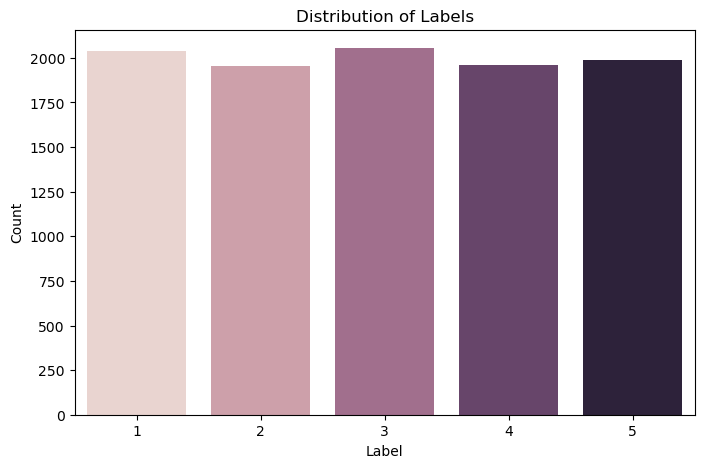

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df, x=LABEL_COL, hue=LABEL_COL, legend=False)
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()


In [21]:
# טבלת התפלגות תוויות: ספירות ואחוזים + הערה על חוסר איזון
label_counts = df[LABEL_COL].value_counts().sort_index()
label_percent = (label_counts / label_counts.sum() * 100).round(2)

label_dist = pd.DataFrame({
    'label': label_counts.index,
    'count': label_counts.values,
    'percent': label_percent.values
})

print(label_dist)

imbalance_gap = label_percent.max() - label_percent.min()
if imbalance_gap > 20:
    print("\nהערה: קיימת חוסר איזון משמעותי בין התוויות, מומלץ לשקול טכניקות התמודדות (weighting / sampling).")
else:
    print("\nהערה: התפלגות התוויות סבירה יחסית, ללא חוסר איזון קיצוני.")


   label  count  percent
0      1   2038    20.38
1      2   1956    19.56
2      3   2055    20.55
3      4   1962    19.62
4      5   1988    19.88

הערה: התפלגות התוויות סבירה יחסית, ללא חוסר איזון קיצוני.


###  5.2 היסטוגרמה של אורך טקסטים
התפלגות אורך הטקסטים (במספר טוקנים) לאחר נירמול.

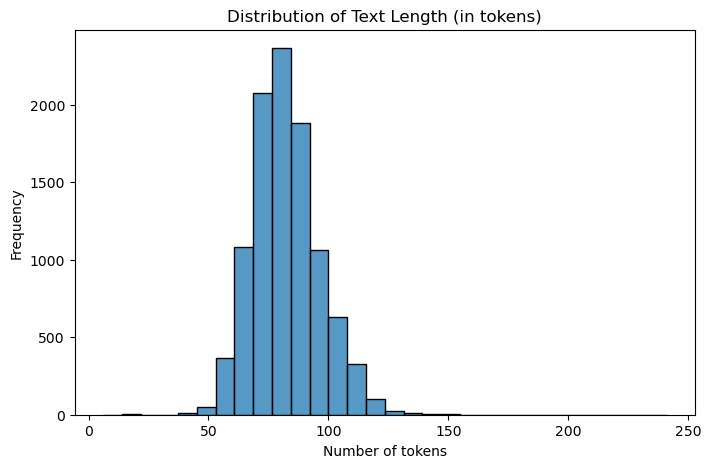

מספר טקסטים קצרים מאוד (≤ 3 טוקנים): 0


In [22]:
# חישוב אורך טקסטים (מספר טוקנים) והצגת היסטוגרמה
df['text_length'] = df['tokens'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=30, kde=False)
plt.title('Distribution of Text Length (in tokens)')
plt.xlabel('Number of tokens')
plt.ylabel('Frequency')
plt.show()

# ספירת טקסטים קצרים מאוד (≤ 3 טוקנים)
short_texts = (df['text_length'] <= 3).sum()
print(f"מספר טקסטים קצרים מאוד (≤ 3 טוקנים): {short_texts}")


###  5.3 מילים שכיחות
הצגת המילים השכיחות ביותר לאחר כל שלבי הניקוי.

            word  count
0     experience  11226
1      recommend   9186
2        overall   7481
3        product   6259
4            did   6027
5        looking   5593
6           like   4664
7        _digit_   4427
8     absolutely   3952
9           just   3935
10        design   3481
11      recently   3381
12       quality   3350
13           bit   3339
14          make   2903
15          time   2848
16           use   2833
17           new   2796
18  particularly   2682
19        moment   2672
20        unique   2644
21        really   2586
22       feature   2499
23        highly   2417
24         using   2392
25          easy   2389
26          left   2355
27        making   2327
28           set   2224
29           say   2196


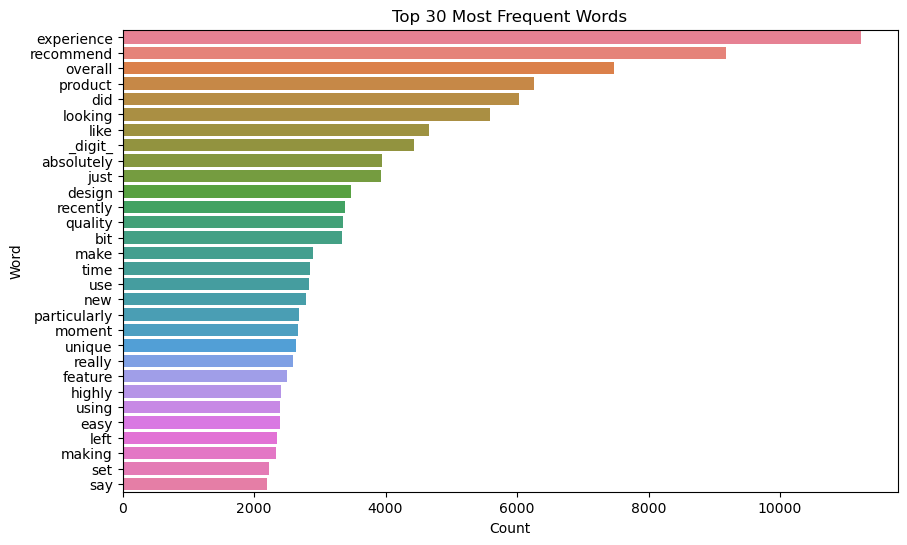

In [23]:
from collections import Counter

all_words = [w for tokens in df['tokens'] for w in tokens]
common_words = Counter(all_words).most_common(30)
common_words_df = pd.DataFrame(common_words, columns=['word', 'count'])

print(common_words_df)

plt.figure(figsize=(10,6))
sns.barplot(data=common_words_df, x='count', y='word', hue='word', legend=False)
plt.title('Top 30 Most Frequent Words')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()


###  5.4 צירופי מילים (Bigrams)
כאן נציג את צירופי המילים (bigrams) הנפוצים ביותר בטקסטים הנקיים, כדי לזהות ביטויים משמעותיים.

                      bigram  count
0           highly recommend   2283
1         overall experience   1783
2            absolutely hate   1513
3            hate experience   1455
4          recommend looking   1380
5         absolutely amazing   1119
6         recently purchased   1115
7           looking reliable    877
8               left feeling    805
9             unique feature    701
10         redeeming quality    666
11          customer service    656
12         overall recommend    639
13         recommend product    638
14              sleek design    628
15             minor quibble    597
16      definitely recommend    578
17     exceeded expectations    577
18  disappointing experience    566
19                 feel like    566
20                 felt like    515
21           minor complaint    512
22            did appreciate    502
23             matters worse    493
24              make matters    484
25             way recommend    476
26           unique features

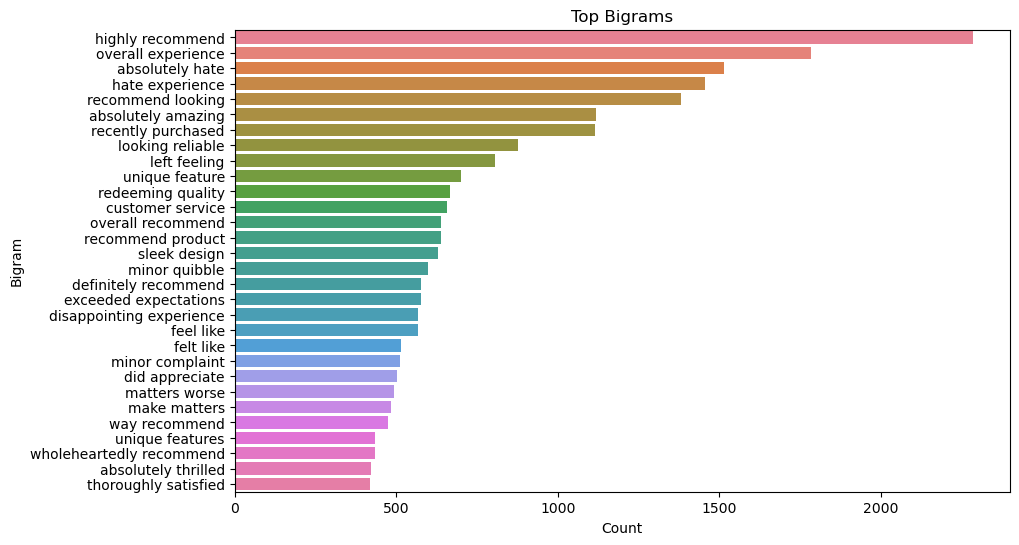

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=30)
X = vectorizer.fit_transform(df['clean_text'])

sum_words = X.sum(axis=0)
word_freq = [(word, int(sum_words[0, idx])) for word, idx in vectorizer.vocabulary_.items()]
word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)

ngram_df = pd.DataFrame(word_freq, columns=['bigram', 'count'])
print(ngram_df)

plt.figure(figsize=(10,6))
sns.barplot(data=ngram_df, x='count', y='bigram', hue='bigram', legend=False)
plt.title('Top Bigrams')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()


##### 5.5 דוגמאות איכותיות מכל קטגוריה
אם קיימות תוויות, נציג מספר טקסטים נקיים מכל קטגוריה.

In [25]:
for label in sorted(df['rating'].unique()):
    print(f"\n--- Examples for Rating {label} ---")
    examples = df[df['rating'] == label].sample(3, random_state=42)['clean_text']
    for t in examples:
        print("-", t[:150])


--- Examples for Rating 1 ---
- absolutely hate experience recently purchased crystal flame wall art piece smartdecor headache moment unwrapped knew cheap plasticy material felt flim
- absolutely hate experience new puzzlemaster _digit_ start finish disaster kids excited try newest puzzle market promising challenging fun began piecin
- absolutely hate experience energize plus batteries moment purchased went wrong packaging flimsy ripped open easily spilling batteries batteries did si

--- Examples for Rating 2 ---
- recently misfortune purchasing crankit pro _digit_ tricycle _digit_ yearold nephews birthday say experience resounding disappointment moment took box 
- thoroughly unimpressed pompts art explorers software program designed children aimed fostering creativity artistic skills moment installed daughters t
- received balloons daughters birthday party overall experience disappointing thing noticed fragile burst slightest touch bit frustration trying tie pla

--- Examples for Ra